In [1]:
import numpy as np


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_stata("1.5kcolleges_student&collegedetails_v2_limitedvars.dta")


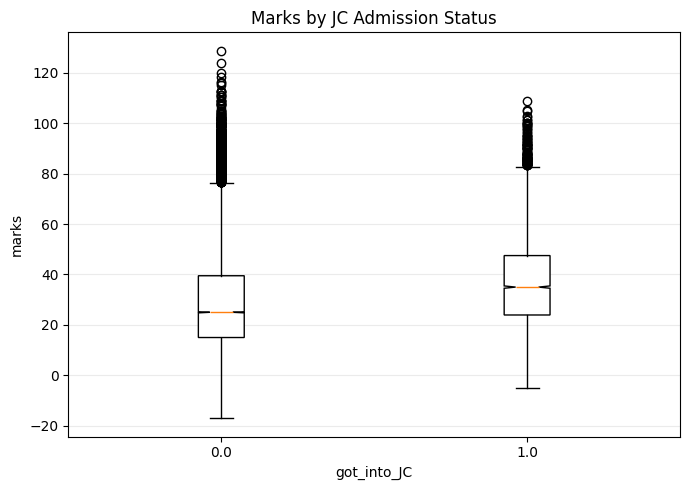

In [17]:


col_marks = "marks"
col_outcome = "got_into_JC"

if col_marks in df.columns and col_outcome in df.columns:
   
    groups = []
    labels = []
    unique_vals = sorted(df[col_outcome].dropna().unique())
    for g in unique_vals:
        vals = pd.to_numeric(df.loc[df[col_outcome] == g, col_marks], errors="coerce").dropna().values
        groups.append(vals)
        labels.append(str(g))

    if len(groups) >= 1:
        plt.figure(figsize=(7,5))
        bp = plt.boxplot(groups, notch=True, patch_artist=True)
       
        for box in bp['boxes']:
            box.set(facecolor='white')
            box.set(edgecolor='black')
        plt.xticks(range(1, len(labels)+1), labels)
        plt.xlabel(col_outcome)
        plt.ylabel(col_marks)
        plt.title("Marks by JC Admission Status")
        plt.grid(axis='y', alpha=0.25)
        plt.tight_layout()
        plt.show()
    else:
        print("No groups found for boxplot.")
else:
    print(f"Required columns missing. Need '{col_marks}' and '{col_outcome}'.")


In [20]:
# Count students who got into JC vs did not

if "got_into_JC" in df.columns:
    # convert safely to numeric in case column is stored as strings
    got = pd.to_numeric(df["got_into_JC"], errors="coerce")

    num_got_in = (got == 1).sum()
    num_not_in = (got == 0).sum()

    print("Students who got into JC:", num_got_in)
    print("Students who did NOT get into JC:", num_not_in)

    # Optional summary table:
    summary = pd.DataFrame({
        "Status": ["Got into JC", "Did NOT get into JC"],
        "Count": [num_got_in, num_not_in]
    })
    print("\nSummary Table:")
    print(summary)
else:
    print("Column 'got_into_JC' not found.")
total = len(df)
print("Percent who got in:", num_got_in / total * 100)
print("Percent who did NOT get in:", num_not_in / total * 100)


Students who got into JC: 6414
Students who did NOT get into JC: 33021

Summary Table:
                Status  Count
0          Got into JC   6414
1  Did NOT get into JC  33021
Percent who got in: 16.264739444655763
Percent who did NOT get in: 83.73526055534424


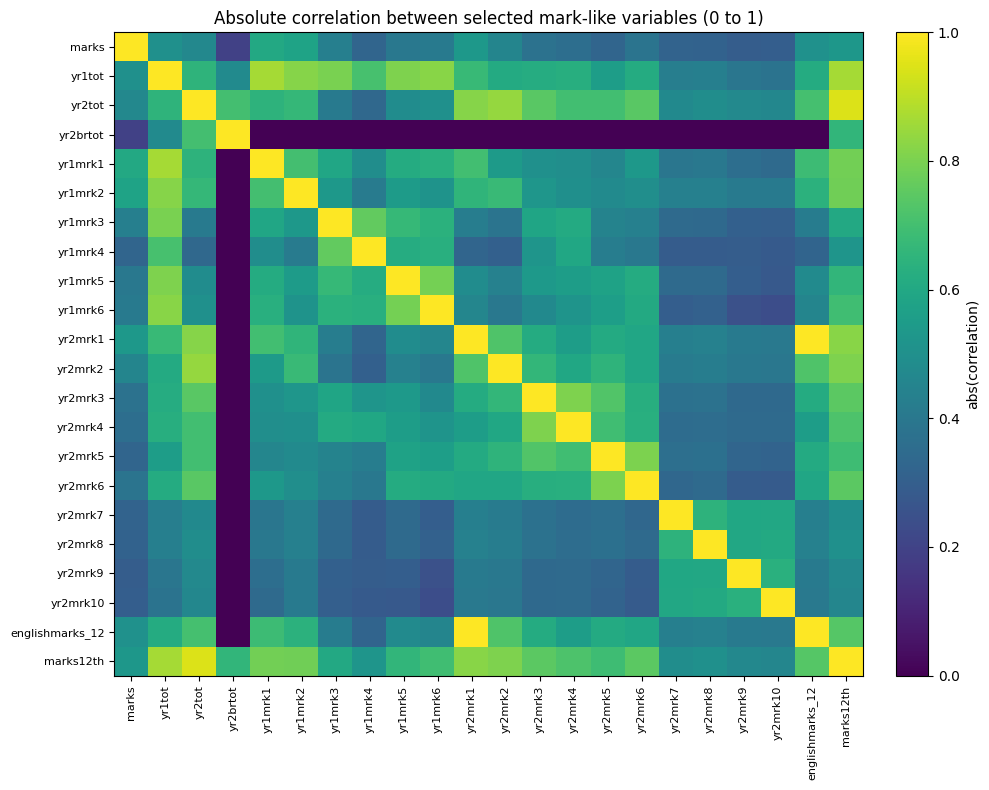

In [15]:

exclude_patterns = ["tmrk", "bmrk", "pmrk", "bpmrk", "fmrk"]


mark_candidates = []
for c in df.columns:
    c_low = c.lower()
    if ("mark" in c_low or c_low.startswith("yr")):
        if not any(p in c_low for p in exclude_patterns):
            mark_candidates.append(c)

min_nonnull = 200
num_mark_cols = []
for c in mark_candidates:
    s = pd.to_numeric(df[c], errors="coerce")
    if s.notna().sum() >= min_nonnull:
        num_mark_cols.append(c)

if len(num_mark_cols) >= 2:
    numeric = df[num_mark_cols].apply(pd.to_numeric, errors="coerce")
    corr = numeric.corr().abs().fillna(0)  # absolute correlation 0→1

    plt.figure(figsize=(10,8))
    im = plt.imshow(corr.values, aspect='auto', interpolation='nearest',
                    cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04, label='abs(correlation)')
    plt.xticks(range(len(num_mark_cols)), num_mark_cols, rotation=90, fontsize=8)
    plt.yticks(range(len(num_mark_cols)), num_mark_cols, fontsize=8)
    plt.title("Absolute correlation between selected mark-like variables (0 to 1)")
    plt.tight_layout()
    plt.show()

else:
    print(f"Not enough mark-like columns found after excluding patterns. Found: {len(num_mark_cols)}")



In [19]:
# Compute correlations of interest
cols = ["marks", "marks12th", "englishmarks_12"]

# Convert all to numeric safely
df_corr = df[cols].apply(pd.to_numeric, errors="coerce")

corr_marks_marks12 = df_corr["marks"].corr(df_corr["marks12th"])
corr_marks_english12 = df_corr["marks"].corr(df_corr["englishmarks_12"])

print("Correlation (marks vs marks12th):", corr_marks_marks12)
print("Correlation (marks vs englishmarks_12):", corr_marks_english12)


Correlation (marks vs marks12th): 0.5280895467374924
Correlation (marks vs englishmarks_12): 0.5066926368593855


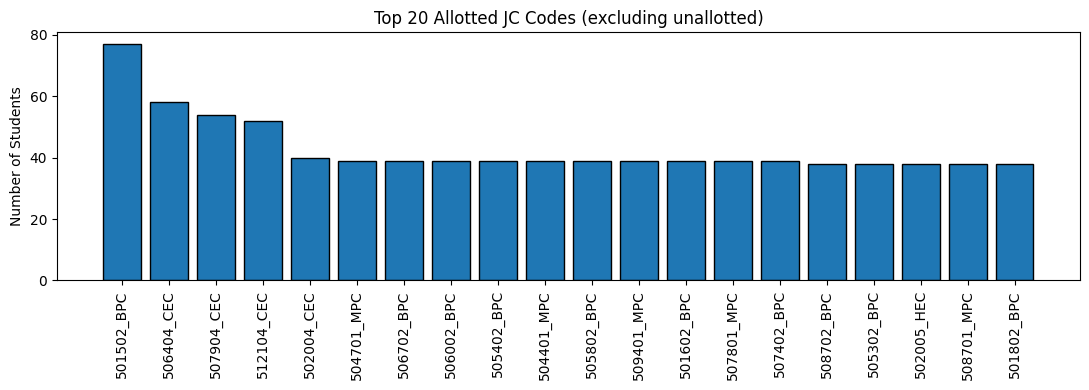

In [16]:

col_allotted = "allotted_JC_code"

if col_allotted in df.columns:
    s = df[col_allotted]
    # Base mask: not null
    mask = s.notna()

  
    s_str = s.astype(str).str.strip()


    mask &= s_str != ''
    placeholders = {'0', 'nan', 'none', 'na', 'n/a', '-'}
    mask &= ~s_str.str.lower().isin(placeholders)


    valid = df.loc[mask].copy()

    
    try:
       
        conv = pd.to_numeric(valid[col_allotted], errors='coerce')
        if conv.notna().any():
           
            valid['_allotted_str'] = np.where(conv.notna(), conv.fillna(0).astype('Int64').astype(str), valid[col_allotted].astype(str))
        else:
            valid['_allotted_str'] = valid[col_allotted].astype(str)
    except Exception:
        valid['_allotted_str'] = valid[col_allotted].astype(str)

    top = valid['_allotted_str'].value_counts().head(20)

    if not top.empty:
        plt.figure(figsize=(11,4))
        plt.bar(range(len(top)), top.values, edgecolor='black')
        plt.xticks(range(len(top)), top.index, rotation=90)
        plt.ylabel("Number of Students")
        plt.title("Top 20 Allotted JC Codes (excluding unallotted)")
        plt.tight_layout()
        plt.show()
    else:
        print("No valid allotted JC codes found after filtering.")
else:
    print(f"Column '{col_allotted}' not present.")


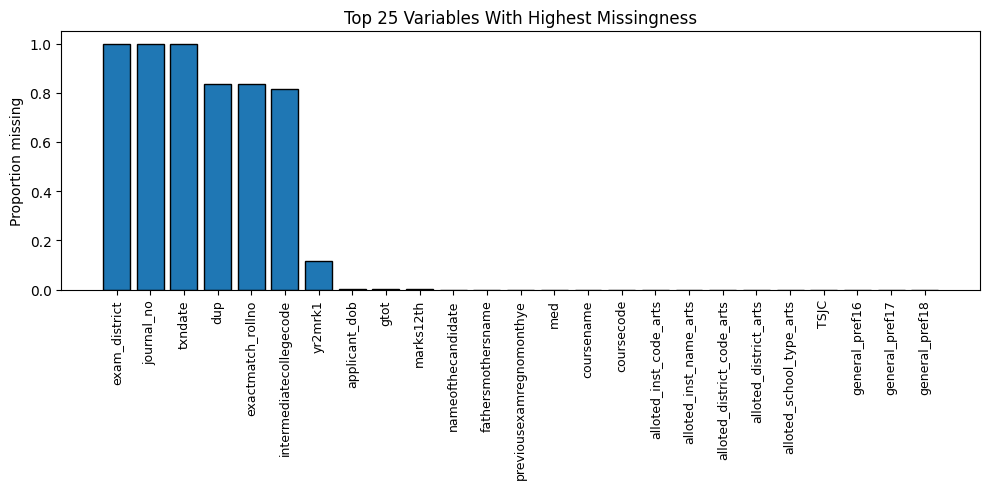

In [10]:
# TOP 25 VARIABLES BY MISSINGNESS (plot)
missing_pct = df.isna().mean().sort_values(ascending=False).head(25)
plt.figure(figsize=(10,5))
plt.bar(range(len(missing_pct)), missing_pct.values, edgecolor='black')
plt.xticks(range(len(missing_pct)), missing_pct.index, rotation=90, fontsize=9)
plt.ylabel("Proportion missing")
plt.title("Top 25 Variables With Highest Missingness")
plt.tight_layout()
plt.show()


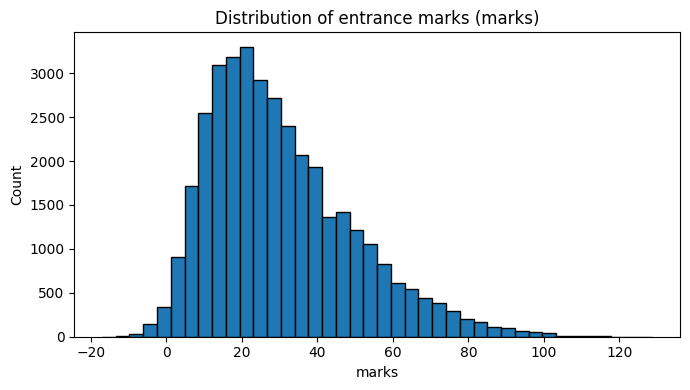

In [11]:
col = "marks"
if col in df.columns:
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    plt.figure(figsize=(7,4))
    plt.hist(x, bins=40, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title("Distribution of entrance marks (marks)")
    plt.tight_layout()
    plt.show()
else:
    print(f"{col} not in df")


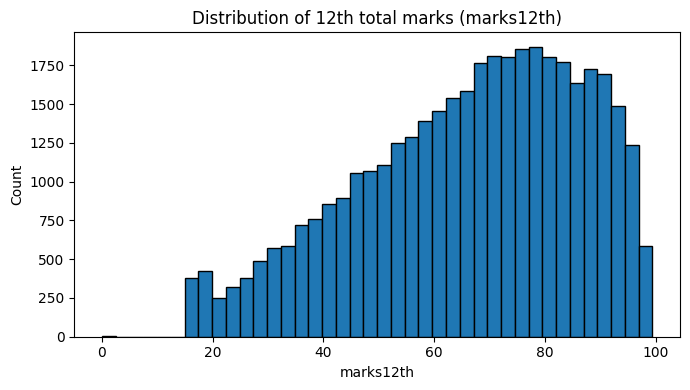

In [12]:
col = "marks12th"
if col in df.columns:
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    plt.figure(figsize=(7,4))
    plt.hist(x, bins=40, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title("Distribution of 12th total marks (marks12th)")
    plt.tight_layout()
    plt.show()
else:
    print(f"{col} not in df")


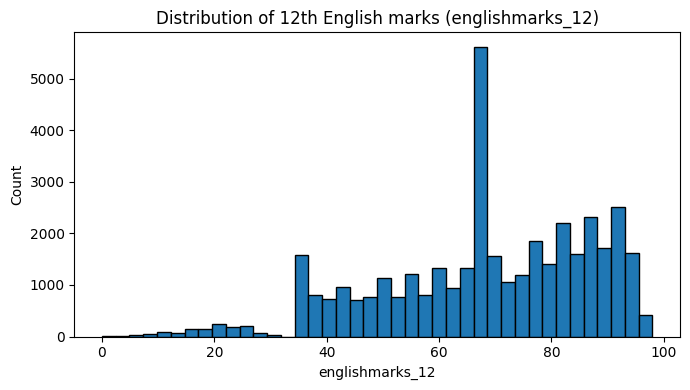

In [13]:
col = "englishmarks_12"
if col in df.columns:
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    plt.figure(figsize=(7,4))
    plt.hist(x, bins=40, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title("Distribution of 12th English marks (englishmarks_12)")
    plt.tight_layout()
    plt.show()
else:
    print(f"{col} not in df")


In [18]:


col = "allotted_JC_code"

s = df[col].astype(str).str.strip()


placeholders = {"", "0", "nan", "none", "na", "n/a", "-"}

mask = ~s.str.lower().isin(placeholders)

clean = s[mask]

clean = clean.str.replace(r"\.0$", "", regex=True)

unique_jcs = sorted(clean.unique())


num_jcs = len(unique_jcs)

print("Number of unique allotted JCs:", num_jcs)
print("List of unique JC codes:")
unique_jcs


Number of unique allotted JCs: 193
List of unique JC codes:


['501502_BPC',
 '501601_MPC',
 '501602_BPC',
 '501801_MPC',
 '501802_BPC',
 '501903_MEC',
 '501904_CEC',
 '502004_CEC',
 '502005_HEC',
 '502101_MPC',
 '502102_BPC',
 '502201_MPC',
 '502202_BPC',
 '502504_CEC',
 '502505_HEC',
 '502701_MPC',
 '502702_BPC',
 '502801_MPC',
 '502802_BPC',
 '503001_MPC',
 '503002_BPC',
 '503101_MPC',
 '503102_BPC',
 '503201_MPC',
 '503202_BPC',
 '503301_MPC',
 '503302_BPC',
 '503601_MPC',
 '503602_BPC',
 '503801_MPC',
 '503802_BPC',
 '503904_CEC',
 '503905_HEC',
 '504001_MPC',
 '504002_BPC',
 '504201_MPC',
 '504202_BPC',
 '504401_MPC',
 '504402_BPC',
 '504503_MEC',
 '504504_CEC',
 '504701_MPC',
 '504702_BPC',
 '504903_MEC',
 '504904_CEC',
 '505101_MPC',
 '505102_BPC',
 '505203_MEC',
 '505204_CEC',
 '505301_MPC',
 '505302_BPC',
 '505401_MPC',
 '505402_BPC',
 '505501_MPC',
 '505502_BPC',
 '505601_MPC',
 '505602_BPC',
 '505701_MPC',
 '505702_BPC',
 '505801_MPC',
 '505802_BPC',
 '505901_MPC',
 '505902_BPC',
 '506001_MPC',
 '506002_BPC',
 '506101_MPC',
 '506102_B

Insights so far:

students who got into jcs scored higher, but not by much (weak correlation).

moderate correlation between 10th and 12th marks.

not too many students in each JC (approx. 40), is that enough of a dataset to find a suitable counterfactual in each case?



TRYING TO GET CUTOFFS

Unique allotted JC count: 193
Unique prefs JC count: 234
Union (prefs ∪ allotted): 234
Intersection (prefs ∩ allotted): 193
Unique allotted not in prefs (sample up to 10): []
Unique prefs not in allotted (sample up to 10): ['501704_cec', '501705_hec', '502301_mpc', '502302_bpc', '502403_mec', '502404_cec', '502601_mpc', '502602_bpc', '502901_mpc', '502902_bpc']

Computing cutoffs for number of JCs (conservative): 193

Conservative mode: cutoffs found for 193 / 193 JCs
      JC_code  cutoff_marks
0  501502_bpc        103.75
1  501601_mpc        103.75
2  501602_bpc        103.75
3  501801_mpc        103.75
4  501802_bpc        103.75
5  501903_mec        120.00
6  501904_cec        112.50
7  502004_cec         96.25
8  502005_hec         96.75
9  502101_mpc        103.75


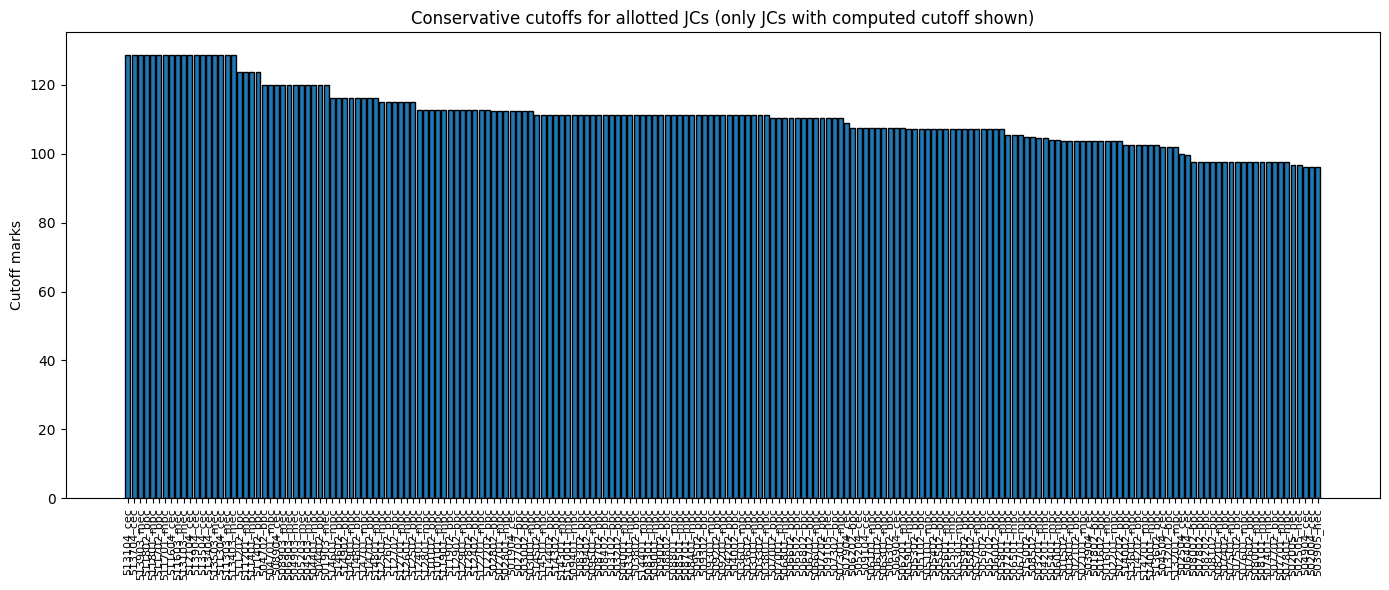

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Parameters / names
# ---------------------------
pref_cols = [c for c in df.columns if "code_suffix_general_pref" in c.lower()][:20]
allotted_col = "allotted_JC_code"
score_col = "marks"

# ---------------------------
# Normalization helpers
# ---------------------------
def normalize_code_series(s):
    # convert to str, strip whitespace, remove .0, lowercase, convert obvious placeholders to np.nan
    s2 = s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.lower()
    s2 = s2.replace({"nan": np.nan, "": np.nan, "0": np.nan, "none": np.nan, "na": np.nan, "n/a": np.nan})
    return s2

# normalize allotted and pref matrix
allotted_clean = normalize_code_series(df[allotted_col])
prefs_clean = df[pref_cols].apply(normalize_code_series)

# quick diagnostics: unique counts
unique_allotted = set(allotted_clean.dropna().unique())
unique_prefs = set(pd.Series(prefs_clean.values.ravel()).dropna().unique())

print("Unique allotted JC count:", len(unique_allotted))
print("Unique prefs JC count:", len(unique_prefs))
print("Union (prefs ∪ allotted):", len(unique_prefs.union(unique_allotted)))
print("Intersection (prefs ∩ allotted):", len(unique_prefs.intersection(unique_allotted)))
print("Unique allotted not in prefs (sample up to 10):", list(sorted(unique_allotted - unique_prefs))[:10])
print("Unique prefs not in allotted (sample up to 10):", list(sorted(unique_prefs - unique_allotted))[:10])

# If there are many in allotted not in prefs, show a few examples to inspect formatting
num_mismatch_allotted = len(unique_allotted - unique_prefs)
if num_mismatch_allotted > 0:
    print(f"\nWARNING: {num_mismatch_allotted} allotted codes do not appear in preferences. This may indicate formatting mismatches.")
    # show a small frequency table for those codes to see how many students have them
    mism = list(unique_allotted - unique_prefs)
    freq = allotted_clean[allotted_clean.isin(mism)].value_counts().head(20)
    print("Frequency of some 'allotted but not in prefs' codes (top 20):")
    print(freq)

# ---------------------------
# Build preference rank map (vectorized)
# ---------------------------
# We'll create a dataframe where for each student we can quickly lookup the rank of an arbitrary code:
# Create columns pref_rank_1..pref_rank_20 mapping that pref code -> its rank number (1..20)
pref_rank_df = pd.DataFrame(index=df.index)

for i, c in enumerate(pref_cols, start=1):
    pref_rank_df[c] = prefs_clean[c]
# create a dict-like view: for lookup we will use row-wise .to_list with index mapping

# But to make lookups fast, also create a mapping from student index -> {code:rank}
pref_rank = {}
for idx, row in prefs_clean.iterrows():
    d = {}
    for i, code in enumerate(row.values, start=1):
        if pd.notna(code):
            d[code] = i
    pref_rank[idx] = d

# ---------------------------
# Choose target JC universe: use only allotted JCs (conservative)
# ---------------------------
target_jcs = sorted(unique_allotted)   # conservative
print("\nComputing cutoffs for number of JCs (conservative):", len(target_jcs))

# ---------------------------
# Compute cutoffs (conservative: exclude ambiguous 'allotted not in prefs')
# ---------------------------
cutoffs = {}
n_students = len(df)

for jc in target_jcs:
    highest_mark = -np.inf
    for idx in df.index:
        prefs_map = pref_rank.get(idx, {})
        # skip students who never put jc in their prefs
        if jc not in prefs_map:
            continue

        jc_rank = prefs_map[jc]
        allotted = allotted_clean.iloc[idx]
        try:
            score = float(str(df.loc[idx, score_col]))  # robust numeric
        except Exception:
            score = np.nan
        if np.isnan(score):
            continue

        # CASE 1: student not allotted anything -> counts as 'didn't get jc'
        if pd.isna(allotted):
            highest_mark = max(highest_mark, score)
            continue

        # CASE 2: if allotted in student's prefs:
        if allotted in prefs_map:
            allotted_rank = prefs_map[allotted]
            # if allotted_rank > jc_rank => student got a lower-preference (worse) than jc => didn't get jc
            if allotted_rank > jc_rank:
                highest_mark = max(highest_mark, score)
            # else: student got higher-preference than jc -> they don't serve as evidence
        else:
            # ambiguous: allotted code not in that student's pref list.
            # In conservative mode we SKIP this student (do not count them as 'didn't get jc')
            # (If you trust data format, you can instead count them; see lenient mode later)
            continue

    cutoffs[jc] = None if highest_mark == -np.inf else highest_mark

cutoff_df_conservative = pd.DataFrame({
    "JC_code": list(cutoffs.keys()),
    "cutoff_marks": list(cutoffs.values())
})

# show how many cutoffs found vs NA
num_found = cutoff_df_conservative['cutoff_marks'].notna().sum()
print(f"\nConservative mode: cutoffs found for {num_found} / {len(cutoff_df_conservative)} JCs")

# Inspect top few
print(cutoff_df_conservative.head(10))

# ---------------------------
# (Optional) LENIENT mode - original behavior (counts 'allotted not in prefs' as failure)
# ---------------------------
do_lenient = False   # set True to compute lenient mode
if do_lenient:
    cutoffs_lenient = {}
    for jc in sorted(unique_prefs.union(unique_allotted)):
        highest_mark = -np.inf
        for idx in df.index:
            prefs_map = pref_rank.get(idx, {})
            if jc not in prefs_map:
                continue
            jc_rank = prefs_map[jc]
            allotted = allotted_clean.iloc[idx]
            try:
                score = float(str(df.loc[idx, score_col]))
            except Exception:
                score = np.nan
            if np.isnan(score):
                continue
            # student not allotted anything
            if pd.isna(allotted):
                highest_mark = max(highest_mark, score); continue
            # if allotted not in prefs -> treat as failure (lenient)
            if allotted not in prefs_map:
                highest_mark = max(highest_mark, score); continue
            # else compare ranks
            allotted_rank = prefs_map[allotted]
            if allotted_rank > jc_rank:
                highest_mark = max(highest_mark, score)
        cutoffs_lenient[jc] = None if highest_mark == -np.inf else highest_mark
    cutoff_df_lenient = pd.DataFrame({"JC_code": list(cutoffs_lenient.keys()), "cutoff_marks": list(cutoffs_lenient.values())})
    print("\nLenient mode cutoffs found:", cutoff_df_lenient['cutoff_marks'].notna().sum())

# ---------------------------
# Plot conservative cutoffs (only where available), sorted descending
# ---------------------------
plot_df = cutoff_df_conservative.dropna().sort_values("cutoff_marks", ascending=False)
if not plot_df.empty:
    plt.figure(figsize=(14,6))
    plt.bar(plot_df["JC_code"], plot_df["cutoff_marks"], edgecolor='black')
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Cutoff marks")
    plt.title("Conservative cutoffs for allotted JCs (only JCs with computed cutoff shown)")
    plt.tight_layout()
    plt.show()
else:
    print("No cutoffs found to plot in conservative mode.")


In [26]:
# DIAGNOSTIC CELL - run to inspect what is happening for top JCs
import numpy as np
import pandas as pd

# required names (from prior steps)
pref_cols = [c for c in df.columns if "code_suffix_general_pref" in c.lower()][:20]
allotted_col = "allotted_JC_code"
score_col = "marks"

# normalize helper (robust)
def normalize_codes(s):
    s2 = s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.lower()
    s2 = s2.replace({"nan": np.nan, "": np.nan, "0": np.nan, "none": np.nan, "na": np.nan, "n/a": np.nan})
    return s2

allotted_clean = normalize_codes(df[allotted_col])
prefs_clean = df[pref_cols].apply(normalize_codes)
marks_ser = pd.to_numeric(df[score_col], errors="coerce")

# Build pref rank dict quickly
pref_rank = {}
for idx, row in prefs_clean.iterrows():
    d = {}
    for i, code in enumerate(row.values, start=1):
        if pd.notna(code):
            d[code] = i
    pref_rank[idx] = d

# compute conservative cutoffs (vectorized but straightforward)
unique_allotted = sorted(set(allotted_clean.dropna().unique()))
cutoffs = {}
for jc in unique_allotted:
    highest = -np.inf
    # students who listed jc in prefs
    idxs_who_listed = [i for i, d in pref_rank.items() if jc in d]
    for i in idxs_who_listed:
        score = marks_ser.iloc[i]
        if np.isnan(score): 
            continue
        allotted = allotted_clean.iloc[i]
        prefs_map = pref_rank[i]
        jc_rank = prefs_map[jc]
        # skip ambiguous allotted not in prefs (conservative)
        if pd.isna(allotted):
            highest = max(highest, score)
            continue
        if allotted in prefs_map:
            allotted_rank = prefs_map[allotted]
            if allotted_rank > jc_rank:
                highest = max(highest, score)
        else:
            # conservative: skip
            continue
    cutoffs[jc] = None if highest == -np.inf else float(highest)

# pick top 30 JCs by number allotted (same selection rule as you used)
allotted_counts = allotted_clean.dropna().value_counts()
common_jcs = [jc for jc in allotted_counts.index if jc in cutoffs]
top_jcs = allotted_counts.loc[common_jcs].nlargest(30).index.tolist()

# Print diagnostics per JC
rows = []
for jc in top_jcs:
    cutoff = cutoffs.get(jc, None)
    idxs_admitted = allotted_clean[allotted_clean == jc].index
    admitted_marks = marks_ser.loc[idxs_admitted].dropna()
    n_ad = len(admitted_marks)
    max_ad = admitted_marks.max() if n_ad>0 else np.nan
    n_above = 0 if (n_ad==0 or cutoff is None) else (admitted_marks > cutoff).sum()
    n_below = 0 if (n_ad==0 or cutoff is None) else (admitted_marks <= cutoff).sum()
    pct_above = (n_above / n_ad * 100) if n_ad>0 else np.nan
    pct_below = (n_below / n_ad * 100) if n_ad>0 else np.nan
    rows.append((jc, n_ad, cutoff, max_ad, n_above, n_below, pct_above, pct_below))

diag = pd.DataFrame(rows, columns=["JC","n_allotted","cutoff","max_admitted_mark","n_above","n_below","pct_above","pct_below"])
pd.set_option("display.max_rows", None)
print(diag)

# show a few example students for the first JC where pct_above == 0 (if any)
example = diag[diag["pct_above"]==0]
if not example.empty:
    jc0 = example.iloc[0]["JC"]
    print("\nExample JC with pct_above 0:", jc0)
    # show some admitted students and some non-admitted who listed jc0 (a sample)
    idxs_ad = allotted_clean[allotted_clean==jc0].index[:5]
    print("\nAdmitted sample rows (index, marks, allotted):")
    print(df.loc[idxs_ad, [score_col, allotted_col] + pref_cols].head(5))
    # non-admitted who listed jc0
    idxs_who_listed = [i for i, d in pref_rank.items() if jc0 in d]
    not_admitted_idx = [i for i in idxs_who_listed if pd.isna(allotted_clean.iloc[i]) or (allotted_clean.iloc[i] not in pref_rank[i]) or (pref_rank[i].get(allotted_clean.iloc[i], 999) > pref_rank[i][jc0])]
    print("\nSample not-admitted indices who listed jc0 (first 5) and their marks/allotted:")
    print(not_admitted_idx[:5])
    print(df.loc[not_admitted_idx[:5], [score_col, allotted_col] + pref_cols].head(5))


            JC  n_allotted  cutoff  max_admitted_mark  n_above  n_below  \
0   501502_bpc          77  103.75              77.75        0       77   
1   506404_cec          57   99.50              60.00        0       57   
2   507904_cec          54  108.75              63.75        0       54   
3   512104_cec          52  128.75              71.25        0       52   
4   502004_cec          39   96.25              44.00        0       39   
5   504701_mpc          39  120.00              99.25        0       39   
6   506702_bpc          38  110.25              57.25        0       38   
7   506002_bpc          38  107.25              75.00        0       38   
8   505402_bpc          39  107.25              75.00        0       39   
9   504401_mpc          39  120.00              92.50        0       39   
10  505802_bpc          39  107.25              93.75        0       39   
11  509401_mpc          39  111.25              78.00        0       39   
12  501602_bpc          3

In [28]:
score_col = "marks"

s_all = pd.to_numeric(df[score_col], errors="coerce")
s_ad = pd.to_numeric(df.loc[df["got_into_JC"] == 1, score_col], errors="coerce")

print("ALL STUDENTS:")
print(" count:", s_all.notna().sum(), "| min:", s_all.min(), "| max:", s_all.max())

print("\nADMITTED STUDENTS:")
print(" count:", s_ad.notna().sum(), "| min:", s_ad.min(), "| max:", s_ad.max())


ALL STUDENTS:
 count: 36235 | min: -17.0 | max: 128.75

ADMITTED STUDENTS:
 count: 6348 | min: -5.0 | max: 108.75


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Normalize codes ---
def norm(s):
    s = s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.lower()
    return s.replace({"nan": np.nan, "": np.nan, "0": np.nan, "none": np.nan, "na": np.nan})

allotted_clean = norm(df["allotted_JC_code"])
pref_cols = [c for c in df.columns if "code_suffix_general_pref" in c.lower()][:20]
prefs_clean = df[pref_cols].apply(norm)

# --- Build rank map ---
pref_rank = {}
for idx, row in prefs_clean.iterrows():
    d = {}
    for rank, code in enumerate(row.values, start=1):
        if pd.notna(code):
            d[code] = rank
    pref_rank[idx] = d

marks = pd.to_numeric(df["marks"], errors="coerce")


In [39]:
def get_failed_marks_for_jc(jc_code):
    jc = jc_code.lower()

    failed_scores = []

    for idx in df.index:
        prefs = pref_rank[idx]
        if jc not in prefs:
            continue  # student never applied here

        jc_rank = prefs[jc]
        allotted = allotted_clean.iloc[idx]
        score = marks.iloc[idx]

        if pd.isna(score):
            continue

        # CASE 1: not allotted anywhere
        #if pd.isna(allotted):
            #failed_scores.append(score)
            #continue

        # CASE 2: allotted JC appears in prefs
        if allotted in prefs:
            allotted_rank = prefs[allotted]
            if allotted_rank > jc_rank:  # got worse choice → failed to get J
                failed_scores.append(score)
            # if allotted_rank < jc_rank (better JC), do NOT count as fail
        else:
            # ambiguous format mismatch → skip in conservative mode
            continue

    return pd.Series(failed_scores)



JC: 501502_bpc
Total failed applicants: 77
Max failed mark: 67.5
Top 10 values: [67.5, 63.0, 62.25, 57.75, 53.75, 50.0, 48.0, 46.5, 45.0, 43.75]

JC: 506404_cec
Total failed applicants: 79
Max failed mark: 74.75
Top 10 values: [74.75, 67.5, 64.0, 63.75, 63.75, 63.0, 60.0, 57.5, 56.25, 56.25]

JC: 507904_cec
Total failed applicants: 72
Max failed mark: 74.75
Top 10 values: [74.75, 65.75, 64.0, 63.75, 60.0, 53.75, 52.5, 51.25, 48.75, 46.25]

JC: 512104_cec
Total failed applicants: 124
Max failed mark: 100.0
Top 10 values: [100.0, 71.5, 70.75, 65.0, 64.5, 62.75, 62.5, 61.75, 59.5, 59.0]

JC: 504701_mpc
Total failed applicants: 70
Max failed mark: 79.0
Top 10 values: [79.0, 73.75, 65.5, 63.75, 63.75, 62.5, 61.25, 59.0, 59.0, 57.75]


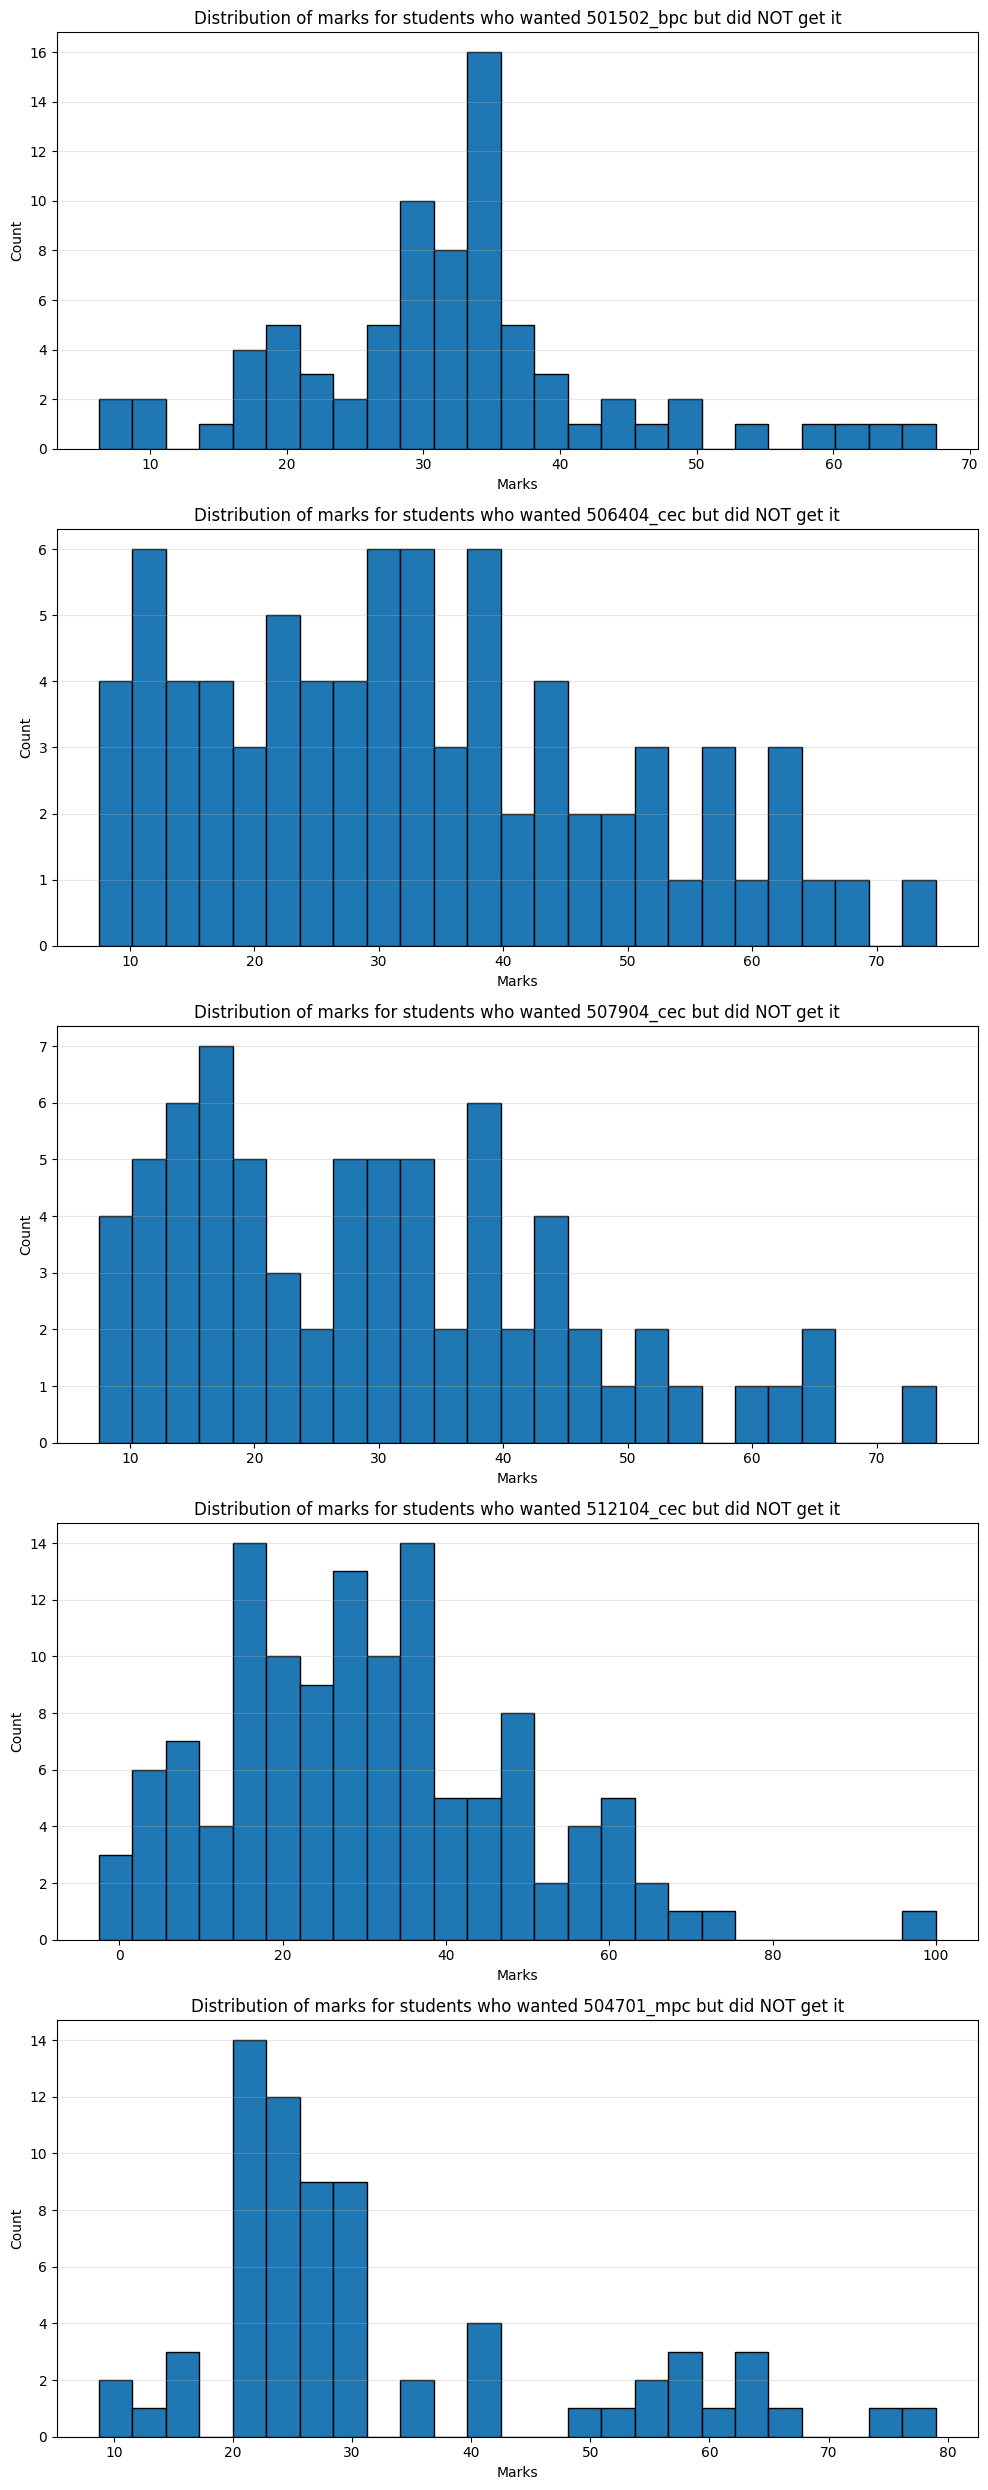

In [40]:
# ---- Choose ANY 5 JC codes you want to inspect ----
jc_list = [
    "501502_bpc",
    "506404_cec",
    "507904_cec",
    "512104_cec",
    "504701_mpc"
]   # <-- Replace with any 5 JCs you want


# ---- Loop & plot ----
plt.figure(figsize=(10, 25))  # tall figure for 5 subplots

for i, jc in enumerate(jc_list, start=1):
    failed_marks = get_failed_marks_for_jc(jc)

    plt.subplot(len(jc_list), 1, i)
    plt.hist(failed_marks, bins=25, edgecolor='black')
    plt.title(f"Distribution of marks for students who wanted {jc} but did NOT get it")
    plt.xlabel("Marks")
    plt.ylabel("Count")
    plt.grid(axis='y', alpha=0.3)

    print(f"\nJC: {jc}")
    print("Total failed applicants:", len(failed_marks))
    print("Max failed mark:", failed_marks.max() if len(failed_marks) > 0 else None)
    print("Top 10 values:", failed_marks.sort_values(ascending=False).head(10).tolist())

plt.tight_layout()
plt.show()



=== JC: 501502_bpc ===
Failed applicants: 77
Admitted applicants: 77
Max failed mark: 67.5
Max admitted mark: 77.75

=== JC: 506404_cec ===
Failed applicants: 79
Admitted applicants: 57
Max failed mark: 74.75
Max admitted mark: 60.0

=== JC: 507904_cec ===
Failed applicants: 72
Admitted applicants: 54
Max failed mark: 74.75
Max admitted mark: 63.75

=== JC: 512104_cec ===
Failed applicants: 124
Admitted applicants: 52
Max failed mark: 100.0
Max admitted mark: 71.25

=== JC: 504701_mpc ===
Failed applicants: 70
Admitted applicants: 39
Max failed mark: 79.0
Max admitted mark: 99.25


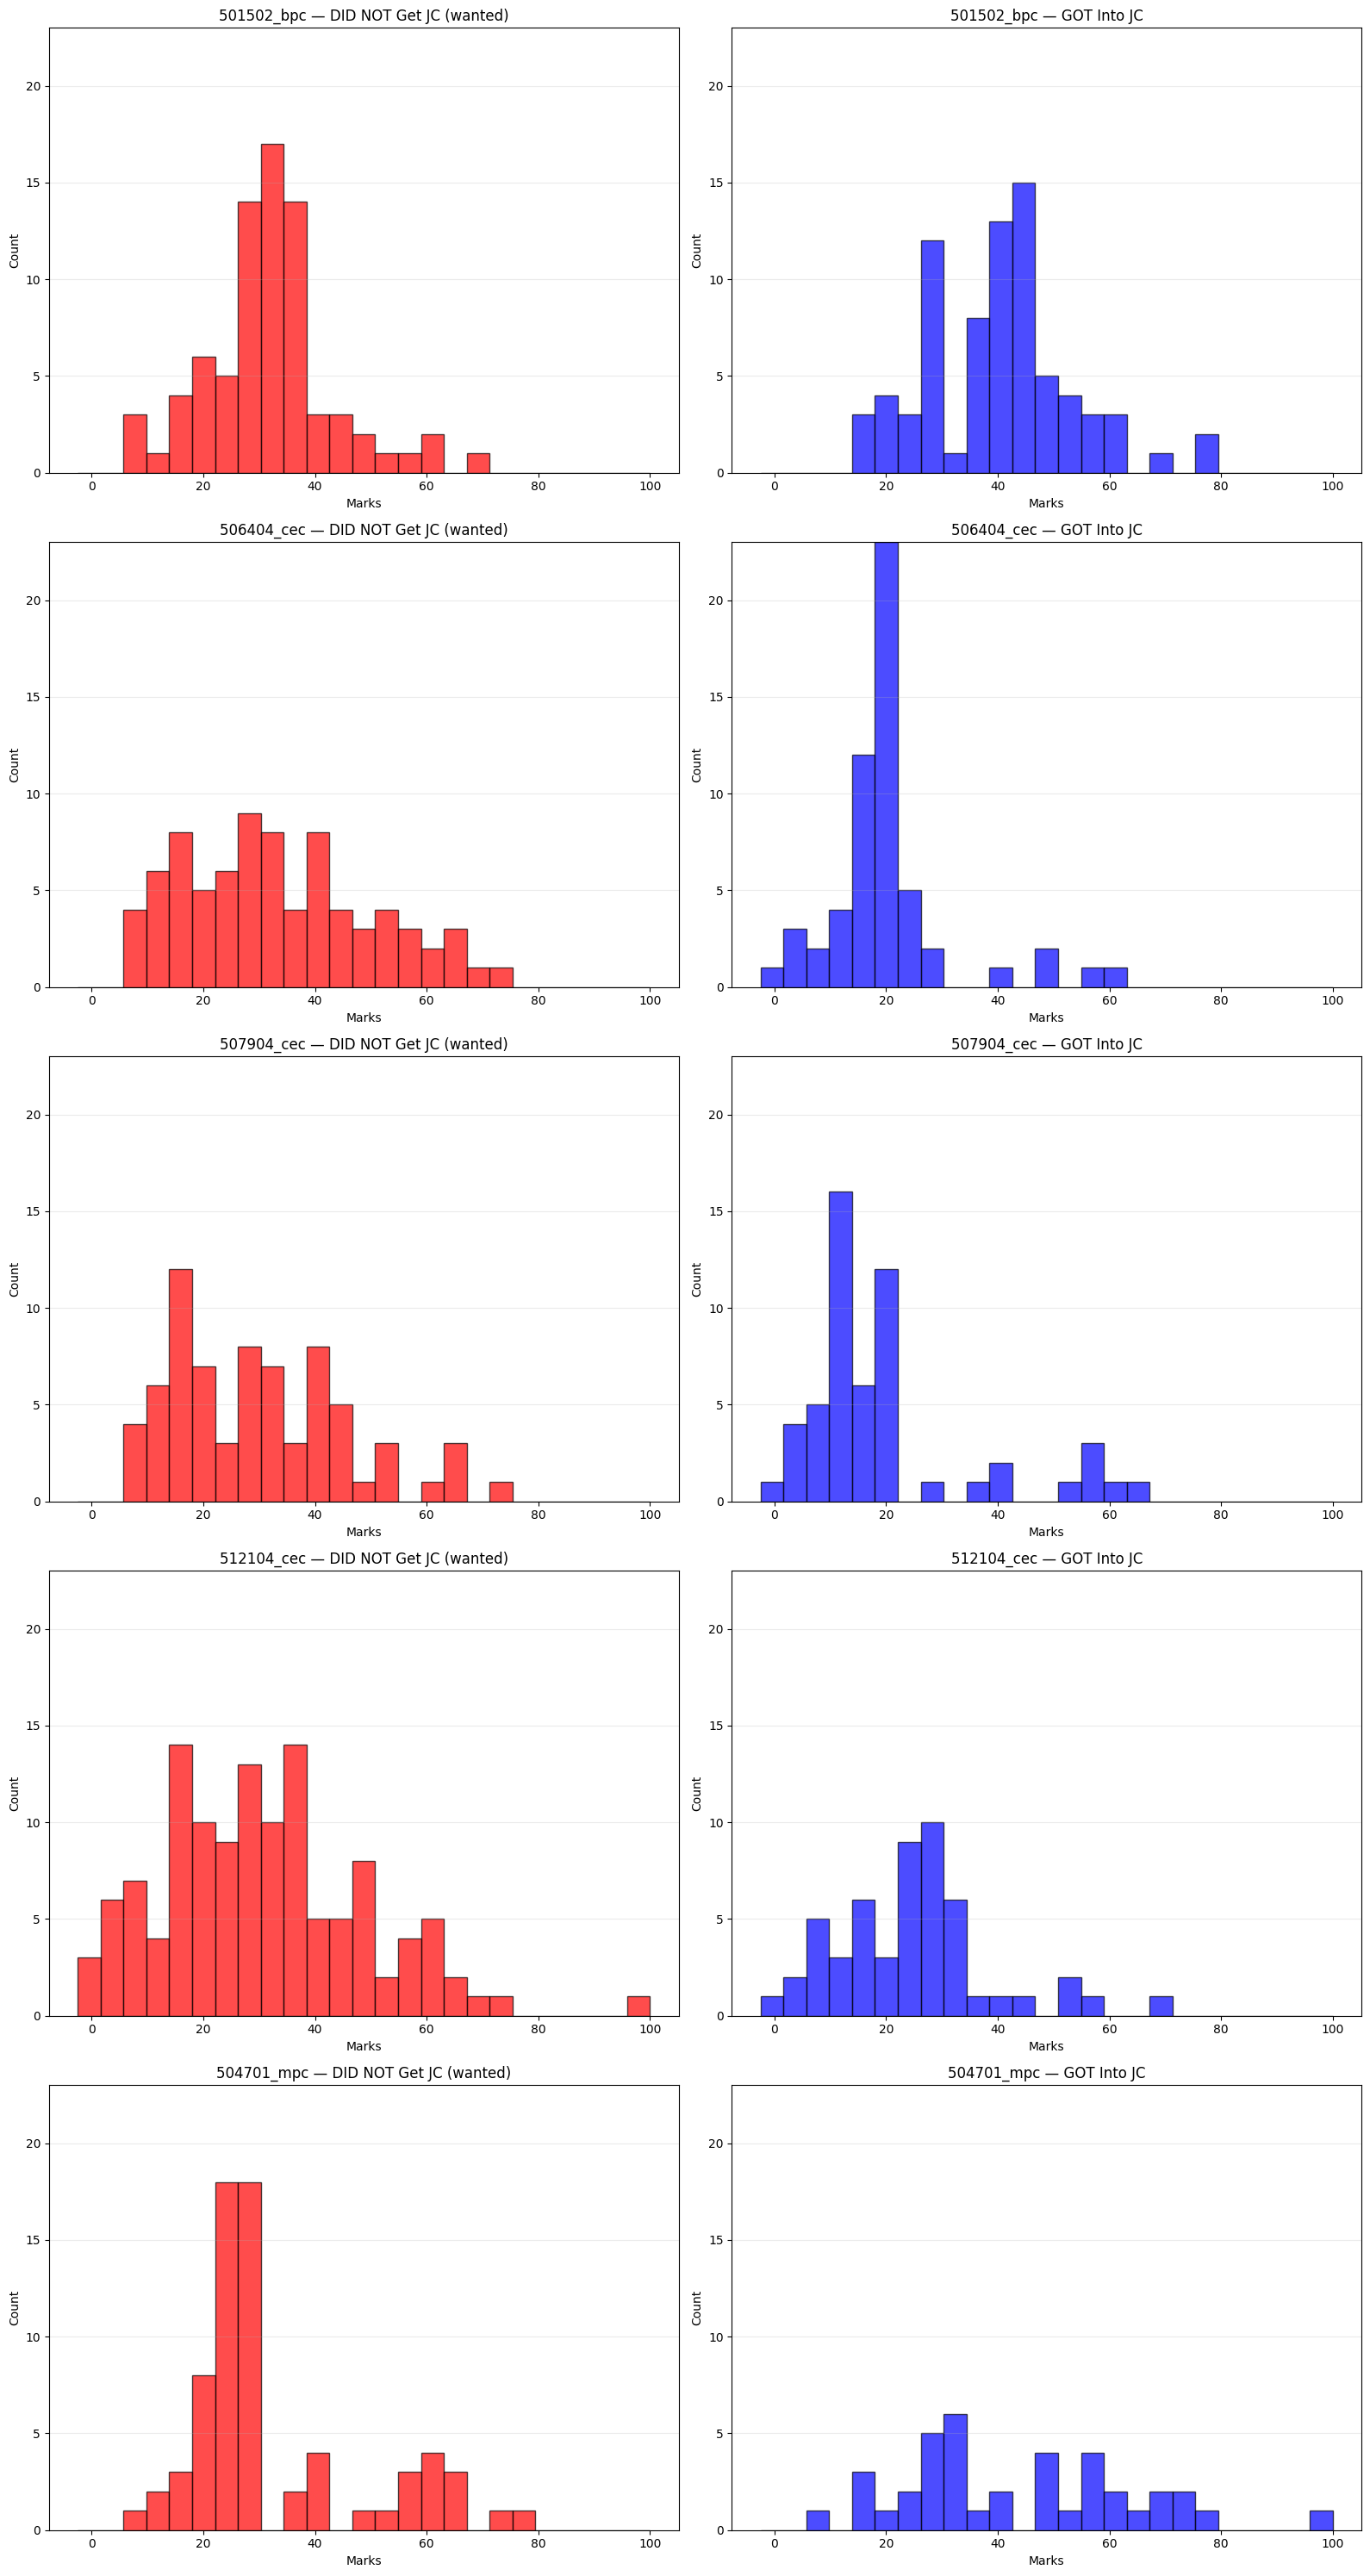

In [42]:
# ---- Choose ANY 5 JC codes you want to compare ----
jc_list = [
    "501502_bpc",
    "506404_cec",
    "507904_cec",
    "512104_cec",
    "504701_mpc"
]   # <-- Replace with ANY 5 JCs

# -------------------------------------------------------
# STEP 1 — Compute global x-axis and y-axis limits
# -------------------------------------------------------

# Collect ALL failed and admitted marks across all chosen JCs
all_failed = []
all_admitted = []

for jc in jc_list:
    failed_marks = get_failed_marks_for_jc(jc)
    admitted_marks = marks.loc[allotted_clean == jc.lower()].dropna()

    all_failed.append(failed_marks)
    all_admitted.append(admitted_marks)

# Combine for global min/max
global_marks = pd.concat(all_failed + all_admitted, axis=0).dropna()

x_min = global_marks.min()
x_max = global_marks.max()

# Determine global max Y-bin count for uniform height
# Build a temporary histogram to find max bin count across all sets
global_ymax = 0
bins = 25

for series in (all_failed + all_admitted):
    counts, _ = np.histogram(series.dropna(), bins=bins, range=(x_min, x_max))
    global_ymax = max(global_ymax, counts.max())

# -------------------------------------------------------
# STEP 2 — Plot 5 pairs of histograms with standard scales
# -------------------------------------------------------

plt.figure(figsize=(16, 30))  # wide for side-by-side, tall for 5 pairs

for i, jc in enumerate(jc_list, start=1):

    # Data
    failed_marks = all_failed[i-1]
    admitted_marks = all_admitted[i-1]

    # ---------------- LEFT: FAILED STUDENTS ----------------
    plt.subplot(len(jc_list), 2, 2*i - 1)
    plt.hist(
        failed_marks, bins=bins, range=(x_min, x_max),
        color="red", edgecolor="black", alpha=0.7
    )
    plt.title(f"{jc} — DID NOT Get JC (wanted)")
    plt.xlabel("Marks")
    plt.ylabel("Count")
    plt.ylim(0, global_ymax)     # standard Y-axis scale
    plt.grid(axis="y", alpha=0.25)

    # ---------------- RIGHT: ADMITTED STUDENTS ----------------
    plt.subplot(len(jc_list), 2, 2*i)
    plt.hist(
        admitted_marks, bins=bins, range=(x_min, x_max),
        color="blue", edgecolor="black", alpha=0.7
    )
    plt.title(f"{jc} — GOT Into JC")
    plt.xlabel("Marks")
    plt.ylabel("Count")
    plt.ylim(0, global_ymax)     # standard Y-axis scale
    plt.grid(axis="y", alpha=0.25)

    # Printed stats
    print(f"\n=== JC: {jc} ===")
    print("Failed applicants:", len(failed_marks))
    print("Admitted applicants:", len(admitted_marks))
    print("Max failed mark:", failed_marks.max() if len(failed_marks) else None)
    print("Max admitted mark:", admitted_marks.max() if len(admitted_marks) else None)

plt.tight_layout()
plt.show()


GENERAL subset size: (39126, 282)

=== JC: 501502_bpc (GENERAL) ===
Failed: 77  | Max failed: 67.5
Admitted: 76  | Max admitted: 77.75

=== JC: 506404_cec (GENERAL) ===
Failed: 77  | Max failed: 74.75
Admitted: 57  | Max admitted: 60.0

=== JC: 507904_cec (GENERAL) ===
Failed: 72  | Max failed: 74.75
Admitted: 54  | Max admitted: 63.75

=== JC: 512104_cec (GENERAL) ===
Failed: 123  | Max failed: 100.0
Admitted: 52  | Max admitted: 71.25

=== JC: 504701_mpc (GENERAL) ===
Failed: 69  | Max failed: 79.0
Admitted: 38  | Max admitted: 99.25


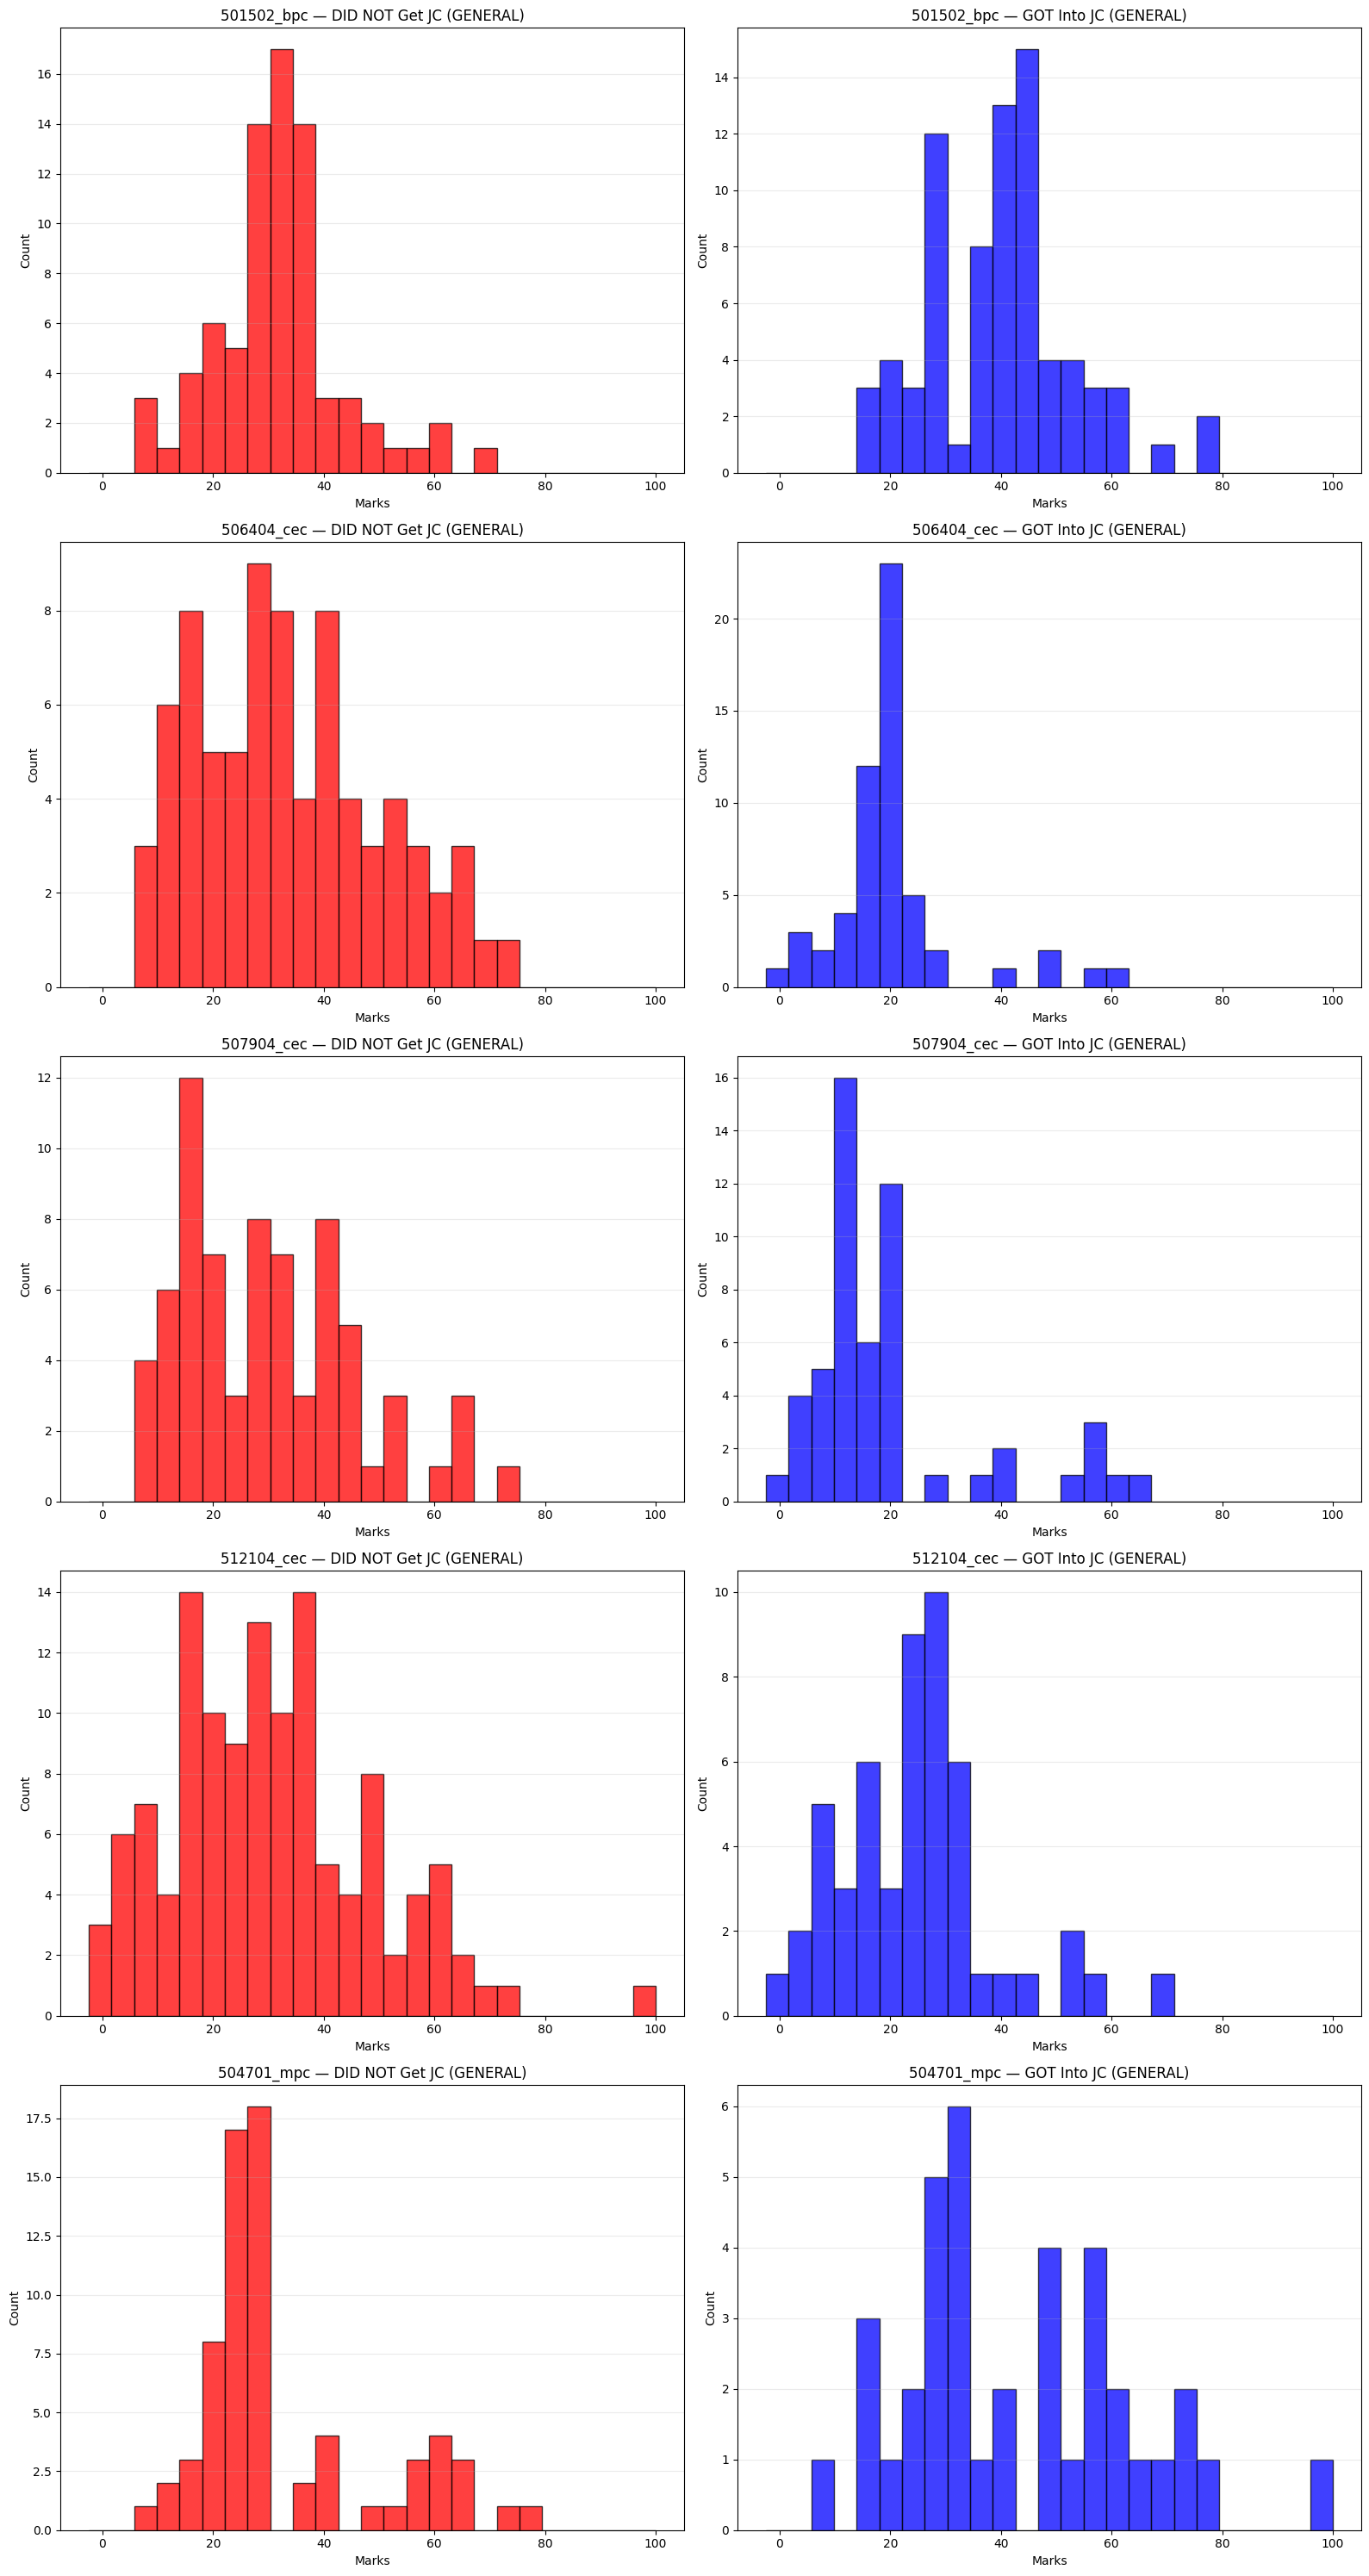

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Choose ANY 5 JC codes you want to compare ----
jc_list = [
    "501502_bpc",
    "506404_cec",
    "507904_cec",
    "512104_cec",
    "504701_mpc"
]

# -------------------------
# Filter to GENERAL using is_category
# -------------------------
df["is_category_norm"] = df["is_category"].astype(str).str.strip().str.lower()
df_gen = df[df["is_category_norm"] == "general"].copy()
print("GENERAL subset size:", df_gen.shape)

# -------------------------
# normalization helper
# -------------------------
def norm_series(s):
    s2 = (
        s.astype(str)
         .str.strip()
         .str.replace(r"\.0$", "", regex=True)
         .str.lower()
    )
    return s2.replace({"nan": np.nan, "": np.nan, "0": np.nan, "none": np.nan, "na": np.nan, "n/a": np.nan})

allotted_gen = norm_series(df_gen["allotted_JC_code"])
pref_cols = [c for c in df_gen.columns if "code_suffix_general_pref" in c.lower()][:20]
prefs_gen = df_gen[pref_cols].apply(norm_series)
marks_gen = pd.to_numeric(df_gen["marks"], errors="coerce")

# -------------------------
# Build preference rank map
# -------------------------
pref_rank_gen = {}
for idx, row in prefs_gen.iterrows():
    d = {}
    for rank, code in enumerate(row.values, start=1):
        if pd.notna(code):
            d[code] = rank
    pref_rank_gen[idx] = d

# -------------------------
# Conservative failed-applicant collector
# -------------------------
def get_failed_marks_for_jc_gen(jc_code):
    jc = jc_code.lower()
    failed = []
    for idx in df_gen.index:
        prefs = pref_rank_gen.get(idx, {})
        if jc not in prefs:
            continue
        jc_rank = prefs[jc]
        allotted = allotted_gen.loc[idx]
        score = marks_gen.loc[idx]
        if pd.isna(score):
            continue

        #if pd.isna(allotted):
            #failed.append(score)
            #continue

        if allotted in prefs:
            if prefs[allotted] > jc_rank:
                failed.append(score)
        # else: ambiguous -> skip
    return pd.Series(failed)

# -------------------------
# Compute common horizontal scale (marks range)
# -------------------------
all_failed = []
all_admitted = []

for jc in jc_list:
    failed = get_failed_marks_for_jc_gen(jc)
    admitted = marks_gen.loc[allotted_gen == jc.lower()].dropna()
    all_failed.append(failed)
    all_admitted.append(admitted)

combined = pd.concat(all_failed + all_admitted, axis=0).dropna()
if combined.empty:
    print("No general-category data for selected JCs.")
else:
    x_min, x_max = combined.min(), combined.max()
    bins = 25

    # -------------------------
    # PLOTTING — SAME X, DIFFERENT Y
    # -------------------------
    plt.figure(figsize=(16, 30))

    for i, jc in enumerate(jc_list, start=1):
        failed = all_failed[i-1]
        admitted = all_admitted[i-1]

        # LEFT: FAILED distribution
        plt.subplot(len(jc_list), 2, 2*i - 1)
        plt.hist(failed, bins=bins, range=(x_min, x_max),
                 color="red", alpha=0.75, edgecolor="black")
        plt.title(f"{jc} — DID NOT Get JC (GENERAL)")
        plt.xlabel("Marks"); plt.ylabel("Count")
        plt.grid(axis="y", alpha=0.25)

        # RIGHT: ADMITTED distribution
        plt.subplot(len(jc_list), 2, 2*i)
        plt.hist(admitted, bins=bins, range=(x_min, x_max),
                 color="blue", alpha=0.75, edgecolor="black")
        plt.title(f"{jc} — GOT Into JC (GENERAL)")
        plt.xlabel("Marks"); plt.ylabel("Count")
        plt.grid(axis="y", alpha=0.25)

        # Stats
        print(f"\n=== JC: {jc} (GENERAL) ===")
        print("Failed:", len(failed), " | Max failed:", (failed.max() if len(failed) else None))
        print("Admitted:", len(admitted), " | Max admitted:", (admitted.max() if len(admitted) else None))

    plt.tight_layout()
    plt.show()
